# Word vectors from SEC filings using Gensim: word2vec model 

## Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
from time import time
import logging

import numpy as np
import pandas as pd

from gensim.models import Word2Vec, KeyedVectors
from gensim.models.word2vec import LineSentence

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [3]:
sns.set_style('white')
np.random.seed(42)

In [4]:
def format_time(t):
    m, s = divmod(t, 60)
    h, m = divmod(m, 60)
    return f'{h:02.0f}:{m:02.0f}:{s:02.0f}'

### Paths

In [5]:
sec_path = Path('..', 'data', 'sec-filings')
ngram_path = sec_path / 'ngrams'

In [6]:
results_path = Path('results', 'sec-filings')

model_path = results_path / 'models'
if not model_path.exists():
    model_path.mkdir(parents=True)

log_path = results_path / 'logs'
if not log_path.exists():
    log_path.mkdir(parents=True)

### Logging Setup

In [7]:
logging.basicConfig(
    filename=log_path / 'word2vec.log',
    level=logging.DEBUG,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%H:%M:%S')

## word2vec

In [8]:
analogies_path = Path('data', 'analogies-en.txt')

### Set up Sentence Generator

In [9]:
NGRAMS = 2

To facilitate memory-efficient text ingestion, the LineSentence class creates a generator from individual sentences contained in the provided text file:

In [10]:
sentence_path = ngram_path  / f'ngrams_{NGRAMS}.txt'
sentences = LineSentence(sentence_path)

### Train word2vec Model

The [gensim.models.word2vec](https://radimrehurek.com/gensim/models/word2vec.html) class implements the skipgram and CBOW architectures.

In [12]:
start = time()
model = Word2Vec(sentences,
                 sg=1,          # 1 for skip-gram; otherwise CBOW
                 hs=0,          # hierarchical softmax if 1, negative sampling if 0
                 vector_size=300,      # Vector dimensionality
                 window=5,      # Max distance betw. current and predicted word
                 min_count=50,  # Ignore words with lower frequency
                 negative=15,    # noise word count for negative sampling
                 workers=4,     # no threads 
                 epochs=1,        # no epochs = iterations over corpus
                 alpha=0.05,   # initial learning rate
                 min_alpha=0.0001 # final learning rate
                ) 
print('Duration:', format_time(time() - start))

Duration: 00:25:32


### Persist model & vectors

In [13]:
model.save((model_path / 'word2vec_0.model').as_posix())
model.wv.save((model_path / 'word_vectors_0.bin').as_posix())

### Load model and vectors

In [14]:
model = Word2Vec.load((model_path / 'word2vec_0.model').as_posix())

In [15]:
wv = KeyedVectors.load((model_path / 'word_vectors_0.bin').as_posix())

### Get vocabulary

In [21]:
model.wv.get_index('reductions')

971

In [25]:
vocab = []
for k, v in model.wv.key_to_index.items():
    count = model.wv.get_vecattr(k, 'count')
    vocab.append([k, v, count])

In [26]:
vocab = (pd.DataFrame(vocab, 
                     columns=['token', 'idx', 'count'])
         .sort_values('count', ascending=False))

In [27]:
vocab.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57654 entries, 0 to 57653
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   token   57654 non-null  object
 1   idx     57654 non-null  int64 
 2   count   57654 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.8+ MB


In [28]:
vocab.head(10)

,token,idx,count
0,million,0,2341204
1,business,1,1702332
2,december,2,1519316
3,company,3,1491418
4,products,4,1368832
5,net,5,1254670
6,market,6,1149269
7,including,7,1109875
8,sales,8,1099626
9,costs,9,1020139


In [29]:
vocab['count'].describe(percentiles=np.arange(.1, 1, .1)).astype(int)

count      57654
mean        4515
std        35185
min           50
10%           60
20%           75
30%           96
40%          127
50%          175
60%          262
70%          440
80%          942
90%         3656
max      2341204
Name: count, dtype: int32

### Evaluate Analogies

In [36]:
def accuracy_by_category(acc, detail=True):
    results = [[c['section'], len(c['correct']), len(c['incorrect'])] for c in acc]
    results = pd.DataFrame(results, columns=['category', 'correct', 'incorrect'])
    results['average'] = results.correct.div(results[['correct', 'incorrect']].sum(1))
    if detail:
        print(results.sort_values('average', ascending=False))
    return results.loc[results.category=='Total accuracy', ['correct', 'incorrect', 'average']].squeeze().tolist()

In [32]:
_, detailed_accuracy = model.wv.evaluate_word_analogies(analogies_path.as_posix(), case_insensitive=True)

In [37]:
summary = accuracy_by_category(detailed_accuracy)

                       category  correct  incorrect   average
10  gram6-nationality-adjective      488        634  0.434938
12                 gram8-plural      265        665  0.284946
9      gram5-present-participle      148        404  0.268116
7             gram3-comparative      285        837  0.254011
13           gram9-plural-verbs       90        290  0.236842
14               Total accuracy     2468       8916  0.216796
2                 city-in-state      877       3365  0.206742
5     gram1-adjective-to-adverb       66        354  0.157143
6                gram2-opposite       52        290  0.152047
11             gram7-past-tense      130        740  0.149425
8             gram4-superlative       44        462  0.086957
0      capital-common-countries       14        226  0.058333
4                        family        3         69  0.041667
3                      currency        5        201  0.024272
1                 capital-world        1        379  0.002632


In [44]:
def eval_analogies(w2v, max_vocab=15000):
    _, accuracy = w2v.wv.evaluate_word_analogies(analogies_path,
                               restrict_vocab=max_vocab,
                               case_insensitive=True)
    return (pd.DataFrame([[c['section'],
                        len(c['correct']),
                        len(c['incorrect'])] for c in accuracy],
                      columns=['category', 'correct', 'incorrect'])
          .assign(average=lambda x: 
                  x.correct.div(x.correct.add(x.incorrect))))  

In [42]:
def total_accuracy(w2v):
    df = eval_analogies(w2v)
    return df.loc[df.category == 'Total accuracy', ['correct', 'incorrect', 'average']].squeeze().tolist()

In [43]:
accuracy = eval_analogies(model)
accuracy

,category,correct,incorrect,average
0,capital-common-countries,0,12,0.000000
1,capital-world,0,0,NaN
2,city-in-state,222,502,0.306630
3,currency,2,50,0.038462
4,family,0,0,NaN
5,gram1-adjective-to-adverb,49,161,0.233333
6,gram2-opposite,23,67,0.255556
7,gram3-comparative,231,369,0.385000
8,gram4-superlative,17,73,0.188889
9,gram5-present-participle,102,204,0.333333


### Validate Vector Arithmetic

In [29]:
sims=model.wv.most_similar(positive=['iphone'], restrict_vocab=15000)
print(pd.DataFrame(sims, columns=['term', 'similarity']))

          term  similarity
0         ipad    0.691182
1      android    0.632260
2          app    0.609227
3   smartphone    0.605110
4  smart_phone    0.580258
5  smartphones    0.577489
6     keyboard    0.559338
7   mobile_app    0.525289
8   downloaded    0.520682
9           pc    0.511132


In [45]:
analogy = model.wv.most_similar(positive=['france', 'london'], 
                                negative=['paris'], 
                                restrict_vocab=15000)
print(pd.DataFrame(analogy, columns=['term', 'similarity']))

             term  similarity
0         germany    0.581994
1  united_kingdom    0.574992
2     netherlands    0.546500
3  germany_france    0.522369
4         belgium    0.521917
5          poland    0.519824
6           italy    0.519173
7       australia    0.501288
8       singapore    0.499383
9          sweden    0.496726


### Check similarity for random words

In [46]:
VALID_SET = 5  # Random set of words to get nearest neighbors for
VALID_WINDOW = 100  # Most frequent words to draw validation set from
valid_examples = np.random.choice(VALID_WINDOW, size=VALID_SET, replace=False)
similars = pd.DataFrame()

for id in sorted(valid_examples):
    word = vocab.loc[id, 'token']
    similars[word] = [s[0] for s in model.wv.most_similar(word)]
similars

,addition,information,credit,table_contents,activities
0,additionally,data,revolving_credit,addition,activity
1,furthermore,details,borrowing,baylake_corp,investing_activities
2,example,stored_transmitted,standings,additionally,financing_activities
3,table_contents,disclosed,credit_facility,december,operations
4,including,databases,revolving,tableofcontents,activites
5,finally,discussion,lenders,s,investing
6,result,transmitting_storing,lending,premierwest,adjustments_reconcile
7,similarly,disclosure,letters_credit,unionbancal,efforts
8,lastly,report,unsecured,revs,nonbanking
9,connection,incorporated_reference,collateral,including,engage


## Continue Training

In [47]:
accuracies = [summary]
best_accuracy = summary[-1]
for i in range(1, 15):
    start = time()
    model.train(sentences, epochs=1, total_examples=model.corpus_count)
    _, detailed_accuracy = model.wv.evaluate_word_analogies(analogies_path)
    accuracies.append(accuracy_by_category(detailed_accuracy, detail=False))
    print(f'{i:02} | Duration: {format_time(time() - start)} | Accuracy: {accuracies[-1][-1]:.2%} ')
    if accuracies[-1][-1] > best_accuracy:
        model.save((model_path / f'word2vec_{i:02}.model').as_posix())
        model.wv.save((model_path / f'word_vectors_{i:02}.bin').as_posix())
        best_accuracy = accuracies[-1][-1]
    (pd.DataFrame(accuracies, 
                 columns=['correct', 'wrong', 'average'])
     .to_csv(model_path / 'accuracies.csv', index=False))
model.wv.save((model_path / 'word_vectors_final.bin').as_posix())

01 | Duration: 00:25:59 | Accuracy: 25.70% 
02 | Duration: 00:26:46 | Accuracy: 29.29% 
03 | Duration: 00:26:15 | Accuracy: 28.68% 
04 | Duration: 00:25:27 | Accuracy: 30.08% 


KeyboardInterrupt: 

### Sample Output


|Epoch|Duration| Accuracy|
|---|---|---|
01 | 00:14:00 | 31.64% | 
02 | 00:14:21 | 31.72% | 
03 | 00:14:34 | 33.65% | 
04 | 00:16:11 | 34.03% | 
05 | 00:13:51 | 33.04% | 
06 | 00:13:46 | 33.28% | 
07 | 00:13:51 | 33.10% | 
08 | 00:13:54 | 34.11% | 
09 | 00:13:54 | 33.70% | 
10 | 00:13:55 | 34.09% | 
11 | 00:13:57 | 35.06% | 
12 | 00:13:38 | 33.79% | 
13 | 00:13:26 | 32.40% | 

In [48]:
(pd.DataFrame(accuracies, 
             columns=['correct', 'wrong', 'average'])
 .to_csv(results_path / 'accuracies.csv', index=False))

In [52]:
best_model = Word2Vec.load((model_path / 'word2vec_04.model').as_posix())

In [53]:
_, detailed_accuracy = best_model.wv.evaluate_word_analogies(analogies_path.as_posix(), case_insensitive=True)

In [54]:
summary = accuracy_by_category(detailed_accuracy)
print('Base Accuracy: Correct {:,.0f} | Wrong {:,.0f} | Avg {:,.2%}\n'.format(*summary))

                       category  correct  incorrect   average
10  gram6-nationality-adjective      593        529  0.528520
2                 city-in-state     1577       2665  0.371759
12                 gram8-plural      326        604  0.350538
7             gram3-comparative      358        764  0.319073
14               Total accuracy     3424       7960  0.300773
9      gram5-present-participle      139        413  0.251812
13           gram9-plural-verbs       90        290  0.236842
5     gram1-adjective-to-adverb       73        347  0.173810
6                gram2-opposite       53        289  0.154971
11             gram7-past-tense      125        745  0.143678
0      capital-common-countries       33        207  0.137500
1                 capital-world       26        354  0.068421
8             gram4-superlative       24        482  0.047431
4                        family        3         69  0.041667
3                      currency        4        202  0.019417
Base Acc

In [55]:
cat_dict = {'capital-common-countries':'Capitals',
            'capital-world':'Capitals RoW',
            'city-in-state':'City-State',
            'currency':'Currency',
            'family':'Famliy',
            'gram1-adjective-to-adverb':'Adj-Adverb',
            'gram2-opposite':'Opposite',
            'gram3-comparative':'Comparative',
            'gram4-superlative':'Superlative',
            'gram5-present-participle':'Pres. Part.',
            'gram6-nationality-adjective':'Nationality',
            'gram7-past-tense':'Past Tense',
            'gram8-plural':'Plural',
            'gram9-plural-verbs':'Plural Verbs',
            'Total accuracy':'Total'}

In [56]:
results = [[c['section'], len(c['correct']), len(c['incorrect'])] for c in detailed_accuracy]
results = pd.DataFrame(results, columns=['category', 'correct', 'incorrect'])
results['category'] = results.category.map(cat_dict)
results['average'] = results.correct.div(results[['correct', 'incorrect']].sum(1))
results = results.rename(columns=str.capitalize).set_index('Category')
total = results.loc['Total']
results = results.drop('Total')

In [57]:
most_sim = best_model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=20)
pd.DataFrame(most_sim, columns=['token', 'similarity'])

,token,similarity
0,women,0.401147
1,men,0.378695
2,spalding,0.374076
3,st_mary,0.361707
4,queen,0.349550
5,female,0.349337
6,alchemy_science,0.348308
7,ebel,0.348137
8,toddlers,0.344483
9,drinker,0.343125


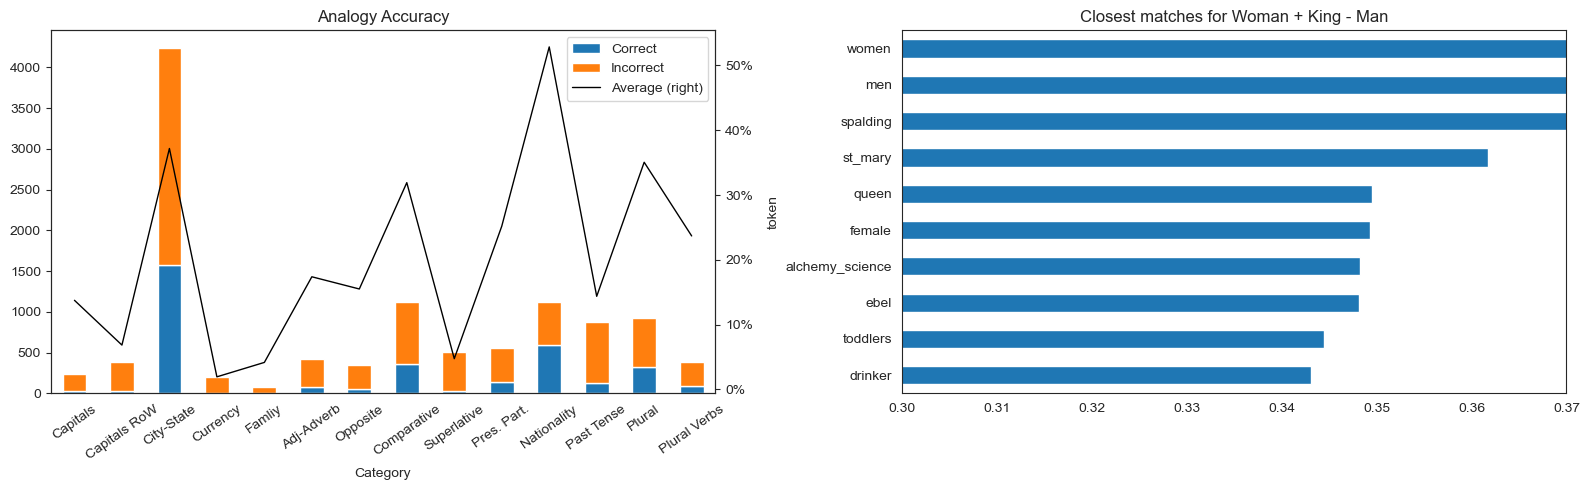

In [58]:
fig, axes = plt.subplots(figsize=(16, 5), ncols=2)

axes[0] = results.loc[:, ['Correct', 'Incorrect']].plot.bar(stacked=True, ax=axes[0]
                                                           , title='Analogy Accuracy')
ax1 = results.loc[:, ['Average']].plot(ax=axes[0], secondary_y=True, lw=1, c='k', rot=35)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

(pd.DataFrame(most_sim, columns=['token', 'similarity'])
 .set_index('token').similarity
 .sort_values().tail(10).plot.barh(xlim=(.3, .37), ax=axes[1], title='Closest matches for Woman + King - Man'))
fig.tight_layout();